# 🧪 Model Lab: Soft Voting Ensemble

이 노트북은 최적화된 로지스틱 회귀, 랜덤 포레스트, XGBoost 모델을 결합한 소프트 보팅(Soft Voting) 앙상블의 성능을 평가합니다.

### 🧪 실험 설정
- **구성 모델:** Logistic Regression, Random Forest, XGBoost
- **결합 방식:** Soft Voting (확률 평균)
- **데이터 분할:** Train(70%) / Val(15%) / Test(15%)
- **평가 지표:** Accuracy, Precision, Recall, F1-Score, ROC-AUC

In [1]:
# 1. 기본 설정
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 7)
sns.set_theme(style="whitegrid")

In [2]:
# 2. 데이터 준비
df = pd.read_csv("../data/processed/selected_features_data.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['Date', 'ticker'])

exclude = ['Date', 'ticker', 'target', 'next_return']
features = [c for c in df.columns if c not in exclude]
X = df[features]
y = df['target']

# 70/15/15 시계열 분할
n = len(df)
tr_idx, val_idx = int(n*0.7), int(n*0.85)

X_train, y_train = X.iloc[:tr_idx], y.iloc[:tr_idx]
X_val, y_val = X.iloc[tr_idx:val_idx], y.iloc[tr_idx:val_idx]
X_test, y_test = X.iloc[val_idx:], y.iloc[val_idx:]

print(f"Train set: {X_train.shape}, Val set: {X_val.shape}, Test set: {X_test.shape}")

Train set: (1024, 25), Val set: (220, 25), Test set: (220, 25)


In [3]:
# 3. 개별 최적 모델 정의 및 소프트 보팅 구성

# 1) Logistic Regression
lr_best = LogisticRegression(
    C=0.05336699231206307, class_weight=None, l1_ratio=0.9, 
    penalty='elasticnet', solver='saga', max_iter=10000, random_state=42
)

# 2) Random Forest
rf_best = RandomForestClassifier(
    n_estimators=200, max_depth=5, min_samples_leaf=4, 
    min_samples_split=10, max_features='sqrt', random_state=42
)

# 3) XGBoost
xgb_best = XGBClassifier(
    n_estimators=200, learning_rate=0.05, max_depth=5, 
    subsample=0.8, colsample_bytree=0.8, eval_metric='logloss', random_state=42
)

# 소프트 보팅 앙상블 구성
voting_clf = VotingClassifier(
    estimators=[
        ('lr', lr_best), 
        ('rf', rf_best), 
        ('xgb', xgb_best)
    ],
    voting='soft'
)

print("--- 소프트 보팅 앙상블 학습 중 ---")
voting_clf.fit(X_train, y_train)

def get_metrics(model, X_set, y_set, label):
    preds = model.predict(X_set)
    probs = model.predict_proba(X_set)[:, 1]
    return {
        'Set': label,
        'Accuracy': accuracy_score(y_set, preds),
        'Precision': precision_score(y_set, preds),
        'Recall': recall_score(y_set, preds),
        'F1': f1_score(y_set, preds),
        'AUC': roc_auc_score(y_set, probs)
    }

results = pd.DataFrame([
    get_metrics(voting_clf, X_train, y_train, 'Train'),
    get_metrics(voting_clf, X_val, y_val, 'Val'),
    get_metrics(voting_clf, X_test, y_test, 'Test')
])

print("\n--- Soft Voting Ensemble Performance ---")
display(results)

--- 소프트 보팅 앙상블 학습 중 ---

--- Soft Voting Ensemble Performance ---


,Set,Accuracy,Precision,Recall,F1,AUC
0,Train,0.973633,0.954861,0.998185,0.976043,0.998738
1,Val,0.504545,0.517241,0.530973,0.524017,0.507650
2,Test,0.477273,0.500000,0.521739,0.510638,0.483230


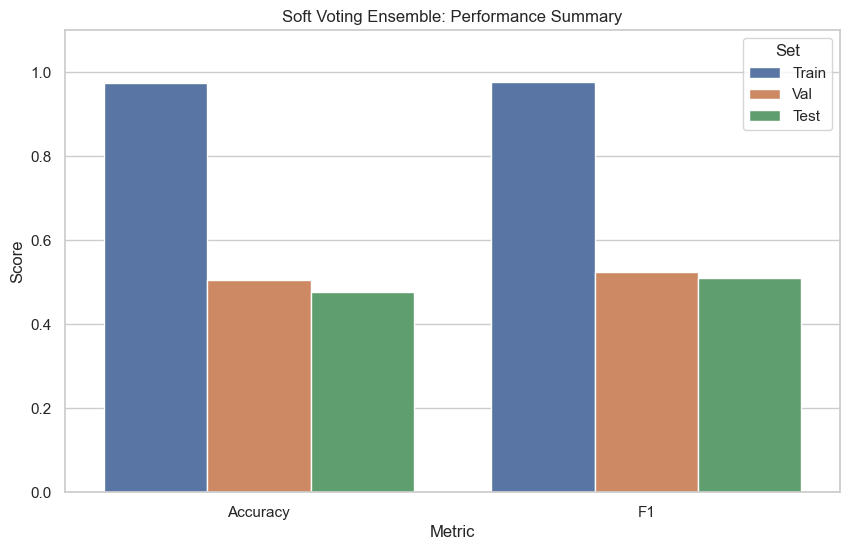

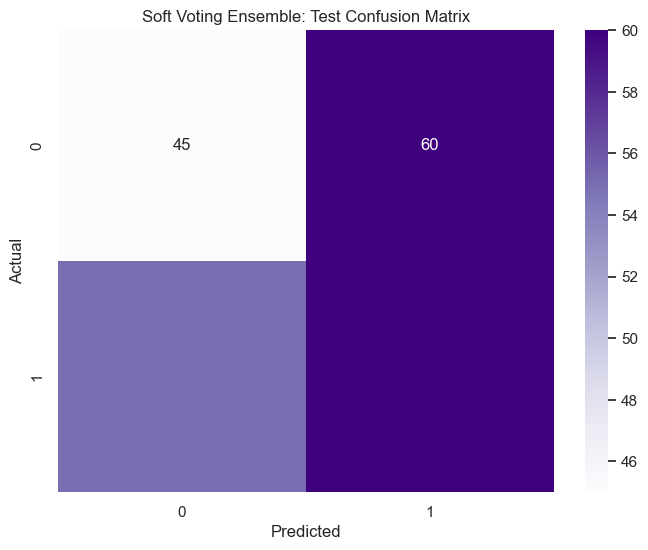

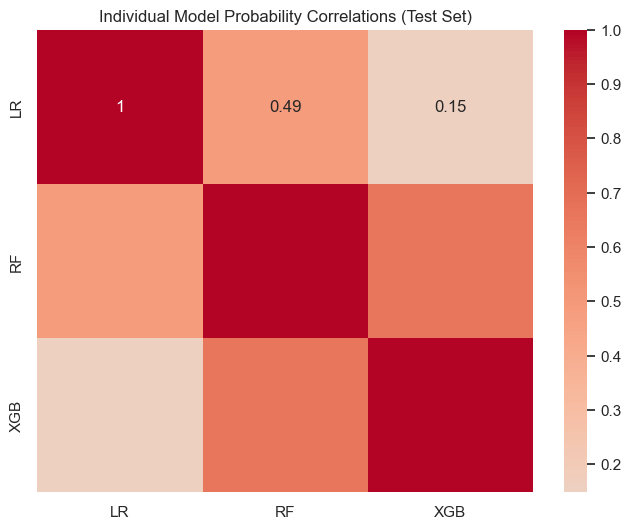

In [4]:
# 4. 결과 시각화

# 1) Accuracy & F1 비교
melted_results = results.melt(id_vars='Set', value_vars=['Accuracy', 'F1'], var_name='Metric', value_name='Score')
plt.figure(figsize=(10, 6))
sns.barplot(data=melted_results, x='Metric', y='Score', hue='Set')
plt.title("Soft Voting Ensemble: Performance Summary")
plt.ylim(0, 1.1)
plt.show()

# 2) 혼동 행렬
y_pred = voting_clf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.title('Soft Voting Ensemble: Test Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 3) 개별 모델 기여도 확인 (확률 상관관계)
test_probs = pd.DataFrame({
    'LR': lr_best.fit(X_train, y_train).predict_proba(X_test)[:, 1],
    'RF': rf_best.fit(X_train, y_train).predict_proba(X_test)[:, 1],
    'XGB': xgb_best.fit(X_train, y_train).predict_proba(X_test)[:, 1]
})

plt.figure(figsize=(8, 6))
sns.heatmap(test_probs.corr(), annot=True, cmap='coolwarm', center=0)
plt.title("Individual Model Probability Correlations (Test Set)")
plt.show()